In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [ ]:
# Import Train, Test

import pickle

with open("../saved_models/ann_final.pkl", "rb") as f:
  ann_final = pickle.load(f)

with open("../saved_models/cnn_final.pkl", "rb") as f:
  cnn_final = pickle.load(f)

with open("../saved_models/labelEncoder.pkl", "rb") as f:
  labelEncoder = pickle.load(f)

In [20]:
# Prepare ANN Data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import models, layers

x_ann = ann_final.drop(columns = ["diagnostic"]).astype(np.float32)
y_ann = ann_final["diagnostic"]

x_train_ann, x_test_ann, y_train_ann, y_test_ann = train_test_split(x_ann, y_ann, test_size = 0.3, random_state = 42, stratify = y_ann)

y_train_ann = labelEncoder.transform(y_train_ann)
y_test_ann = labelEncoder.transform(y_test_ann)

y_train_ann = tf.keras.utils.to_categorical(y_train_ann)
y_test_ann = tf.keras.utils.to_categorical(y_test_ann)

print(labelEncoder.classes_)

['ACK' 'BCC' 'MEL' 'NEV' 'SCC' 'SEK']


In [21]:
# Prepare CNN Data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import models, layers

imgs = []
labels = []

for i in range(len(cnn_final)):
  image = cv2.imread(cnn_final["img_id"][i])
  image_resize = cv2.resize(image, (224, 224))
  image_rgb = cv2.cvtColor(image_resize, cv2.COLOR_BGR2RGB)
  imgs.append(image_rgb)
  labels.append(cnn_final["diagnostic"][i])

tempImgs = np.array(imgs)
tempLabels = np.array(labels)

x_train_cnn, x_test_cnn, y_train_cnn, y_test_cnn = train_test_split(tempImgs, tempLabels, test_size = 0.3, random_state = 42, stratify = tempLabels)

x_train_cnn = x_train_cnn.astype("float32") / 255.0
x_test_cnn = x_test_cnn.astype("float32") / 255.0

y_train_cnn = labelEncoder.transform(y_train_cnn)
y_test_cnn = labelEncoder.transform(y_test_cnn)

y_train_cnn = tf.keras.utils.to_categorical(y_train_cnn)
y_test_cnn = tf.keras.utils.to_categorical(y_test_cnn)

In [ ]:
# Final Classification

import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from keras.layers import Dense, Dropout

cnn_tf_model = tf.keras.models.load_model("../saved_models/cnn_tf_model.keras")
ann_model = tf.keras.models.load_model("../saved_models/ann_model.keras")

cnn_predictions_train = cnn_tf_model.predict(x_train_cnn)
cnn_predictions_test = cnn_tf_model.predict(x_test_cnn)

81/81 ━━━━━━━━━━━━━━━━━━━━ 69s 820ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 620ms/step


In [23]:
# Concatenate Results

ann_predictions_train = ann_model.predict(x_train_ann) * 2
ann_predictions_test = ann_model.predict(x_test_ann) * 2

final_x_train = np.concatenate([cnn_predictions_train, ann_predictions_train], axis = 1)
final_x_test = np.concatenate([cnn_predictions_test, ann_predictions_test], axis = 1)

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [24]:
print(y_train_ann[0])

[0. 1. 0. 0. 0. 0.]


In [25]:
# Class Weights

from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
  class_weight = "balanced",
  classes = np.unique(np.argmax(y_train_ann, axis = 1)),
  y = np.argmax(y_train_ann, axis = 1)
)

class_weights_dict = dict(enumerate(class_weights))

print(class_weights_dict)
print(np.unique(y_train_ann))

{0: np.float64(0.5313919867823214), 1: np.float64(0.4457726957726958), 2: np.float64(8.09119496855346), 3: np.float64(1.5153121319199059), 4: np.float64(2.2104810996563575), 5: np.float64(1.5650851581508516)}
[0. 1.]


In [26]:
# Convert Y Labels To One Number

y_train_ann = np.argmax(y_train_ann, axis = 1)
y_test_ann = np.argmax(y_test_ann, axis = 1)

In [35]:
# Initalize Models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.naive_bayes import GaussianNB
import lightgbm as lgb

logistic_clf = LogisticRegression(multi_class = "multinomial", max_iter = 1000, class_weight = class_weights_dict)
gb_clf = GradientBoostingClassifier()
rf_clf = RandomForestClassifier(n_estimators = 100, class_weight = class_weights_dict)
knn_clf = KNeighborsClassifier(n_neighbors = 7)
svm_clf = SVC(probability = True, class_weight = class_weights_dict)
xgb_clf = xgb.XGBClassifier(use_label = False, eval_metric = "mlogloss", class_weight = class_weights_dict)
lgb_clf = lgb.LGBMClassifier(objective="multiclass", num_class = 6, metric = "multi_logloss", class_weight = class_weights_dict)
nb_clf = GaussianNB()

In [36]:
# Fit Each Model

logistic_clf.fit(final_x_train, y_train_ann)
gb_clf.fit(final_x_train, y_train_ann)
rf_clf.fit(final_x_train, y_train_ann)
knn_clf.fit(final_x_train, y_train_ann)
svm_clf.fit(final_x_train, y_train_ann)
xgb_clf.fit(final_x_train, y_train_ann)
lgb_clf.fit(final_x_train, y_train_ann)
nb_clf.fit(final_x_train, y_train_ann)

c:\ProgramData\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\ProgramData\miniconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:18:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "class_weight", "use_label" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000397 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3054
[LightGBM] [Info] Number of data points in the train set: 2573, number of used features: 12
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791760
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

,priors,None
,var_smoothing,1e-09


In [37]:
# Predictions Of Each Model

logistic_pred = logistic_clf.predict(final_x_test)
gb_pred = gb_clf.predict(final_x_test)
rf_pred = rf_clf.predict(final_x_test)
knn_pred = knn_clf.predict(final_x_test)
svm_pred = svm_clf.predict(final_x_test)
xgb_pred = xgb_clf.predict(final_x_test)
lgb_pred = lgb_clf.predict(final_x_test)
nb_pred = nb_clf.predict(final_x_test)

c:\ProgramData\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [38]:
# Accuracy Of Each Model

from sklearn.metrics import accuracy_score

logistic_acc = accuracy_score(y_test_ann, logistic_pred)
gb_acc = accuracy_score(y_test_ann, gb_pred)
rf_acc = accuracy_score(y_test_ann, rf_pred)
knn_acc = accuracy_score(y_test_ann, knn_pred)
svm_acc = accuracy_score(y_test_ann, svm_pred)
xgb_acc = accuracy_score(y_test_ann, xgb_pred)
lgb_acc = accuracy_score(y_test_ann, lgb_pred)
nb_acc = accuracy_score(y_test_ann, nb_pred)

In [39]:
# Print Accuracy

print(f"Random Forest Accuracy:       {rf_acc}")
print(f"XGB Accuracy:                 {xgb_acc}")
print(f"LGB Accuracy:                 {lgb_acc}")
print(f"Gradient Boosting Accuracy:   {gb_acc}")
print(f"KNN Accuracy:                 {knn_acc}")
print(f"SVM Accuracy:                 {svm_acc}")
print(f"Logistic Regression Accuracy: {logistic_acc}")
print(f"NB Accuracy:                  {nb_acc}")

Random Forest Accuracy:       0.9755434782608695
XGB Accuracy:                 0.9846014492753623
LGB Accuracy:                 0.9855072463768116
Gradient Boosting Accuracy:   0.9782608695652174
KNN Accuracy:                 0.9538043478260869
SVM Accuracy:                 0.9492753623188406
Logistic Regression Accuracy: 0.9483695652173914
NB Accuracy:                  0.947463768115942


In [46]:
from sklearn.ensemble import VotingClassifier

ensemble_clf = VotingClassifier(
  estimators = [
    ("xgb", xgb_clf),
    ("lgb", lgb_clf),
    ("gb", gb_clf),
  ],
  voting = "soft",
  weights = [xgb_acc, lgb_acc, gb_acc]
)

ensemble_clf.fit(final_x_train, y_train_ann)

c:\ProgramData\miniconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:21:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "class_weight", "use_label" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000297 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3054
[LightGBM] [Info] Number of data points in the train set: 2573, number of used features: 12
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791760
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

,estimators,"[('xgb', ...), ('lgb', ...), ...]"
,voting,'soft'
,weights,"[0.9846014492753623, 0.9855072463768116, ...]"
,n_jobs,None
,flatten_transform,True
,verbose,False
,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None


In [72]:
# Evaluate The model

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score, precision_score, roc_auc_score, balanced_accuracy_score

y_pred = ensemble_clf.predict(final_x_test)
y_proba = ensemble_clf.predict_proba(final_x_test)

ensemble_cm = confusion_matrix(y_test_ann, y_pred)
ensemble_ac = accuracy_score(y_test_ann, y_pred)
ensemble_bacc = balanced_accuracy_score(y_test_ann, y_pred)
ensemble_rc = recall_score(y_test_ann, y_pred, average = "macro")
ensemble_pr = precision_score(y_test_ann, y_pred, average = "macro")
ensemble_f1 = f1_score(y_test_ann, y_pred, average = "macro")
ensemble_auc = roc_auc_score(y_test_ann, y_proba, multi_class = "ovr", average = "macro")

print(f"Confusion Matrix:\n {ensemble_cm}")
print(f"Accuracy: {ensemble_ac}")
print(f"BACC: {ensemble_bacc}")
print(f"Recall: {ensemble_rc}")
print(f"Precision: {ensemble_pr}")
print(f"F1-Score: {ensemble_f1}")
print(f"AUC: {ensemble_auc}")

Confusion Matrix:
 [[339   2   0   1   3   1]
 [  2 411   0   0   0   0]
 [  0   0  23   0   0   0]
 [  0   0   0 122   0   0]
 [  0   1   0   0  82   0]
 [  3   2   0   0   0 112]]
Accuracy: 0.9864130434782609
BACC: 0.9866904892681557
Recall: 0.9866904892681557
Precision: 0.9868620215066405
F1-Score: 0.986697779057428
AUC: 0.9978756651545831


c:\ProgramData\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\ProgramData\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


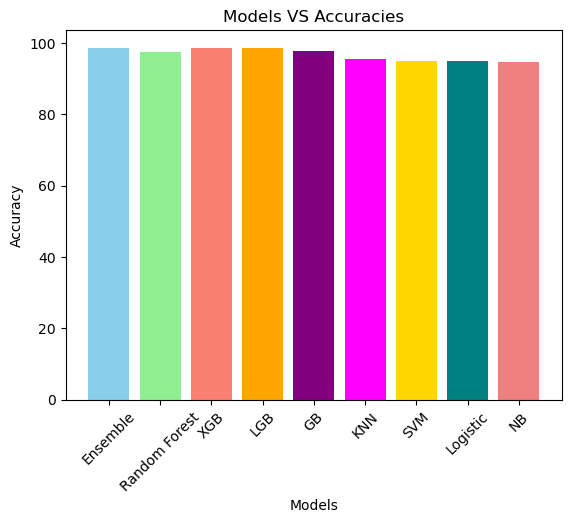

In [81]:
# Plot Accuracies

models = ["Ensemble", "Random Forest", "XGB", "LGB", "GB", "KNN", "SVM", "Logistic", "NB"]
accuracies = [ensemble_ac * 100, rf_acc * 100, xgb_acc * 100, lgb_acc * 100, gb_acc * 100, knn_acc * 100, svm_acc * 100, logistic_acc * 100, nb_acc * 100]
colors = ["skyblue", "lightgreen", "salmon", "orange", "purple", "magenta", "gold", "teal", "lightcoral"]

plt.bar(models, accuracies, color = colors)

plt.title("Models VS Accuracies")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation = 45)
plt.show()

In [ ]:
# Save Models

with open("../saved_models/ensemble_clf.pki", "wb") as f:
  pickle.dump(ensemble_clf, f)

with open("../saved_models/xgb_clf.pki", "wb") as f:
  pickle.dump(xgb_clf, f)

with open("../saved_models/lgb_clf.pki", "wb") as f:
  pickle.dump(lgb_clf, f)

with open("../saved_models/gb_clf.pki", "wb") as f:
  pickle.dump(gb_clf, f)
